### Student Information
Name: Javio Felix (方浩偉)

Student ID: R14K47026

GitHub ID: Irl-Felix

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their labels. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1 - Begin Assignment Here

### Data Source,Data Preparation(Just loaded from CSV)

In [ ]:
# System & Utilities
import os
import random
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
%matplotlib inline

from sklearn import preprocessing, metrics, decomposition, pipeline, dummy
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from umap import UMAP

from scipy.sparse import hstack, csr_matrix

import nltk
# nltk.download("punkt")
# nltk.download("punkt_tab")

import helpers.data_mining_helpers as dmh

In [2]:
#Loading the csv File into a DataFrame.
df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv")

##### Getting Familiar with the Data - a

In [3]:
#Shape & column overview
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (847, 16)
Columns: ['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url', 'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity', 'polarity', 'sentiment', 'entities', 'label']


In [4]:
#Check the first 5 of the whole dataframe
df.head()

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


In [5]:
# Data types & info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          847 non-null    object 
 1   datetime      847 non-null    object 
 2   post_id       847 non-null    object 
 3   subreddit     847 non-null    object 
 4   title         847 non-null    object 
 5   author        847 non-null    object 
 6   url           847 non-null    object 
 7   upvotes       847 non-null    int64  
 8   downvotes     64 non-null     float64
 9   upvote_ratio  64 non-null     float64
 10  text          847 non-null    object 
 11  subjectivity  847 non-null    float64
 12  polarity      847 non-null    float64
 13  sentiment     847 non-null    float64
 14  entities      847 non-null    object 
 15  label         847 non-null    float64
dtypes: float64(6), int64(1), object(9)
memory usage: 106.0+ KB


In [6]:
# Unique values in type and subreddit
print("Type counts:\n", df["type"].value_counts(), "\n")
print("Subreddit counts:\n", df["subreddit"].value_counts(), "\n")

# Sentiment and label distributions
print("Sentiment counts:\n", df["sentiment"].value_counts(), "\n")
print("Label counts:\n", df["label"].value_counts(), "\n")

# Text length overview
df["text_len"] = df["text"].str.len()

Type counts:
 type
comment    783
post        64
Name: count, dtype: int64 

Subreddit counts:
 subreddit
stocks              274
StockMarket         250
stockstobuytoday    174
wallstreetbets      149
Name: count, dtype: int64 

Sentiment counts:
 sentiment
 0.0    331
 1.0    319
-1.0    197
Name: count, dtype: int64 

Label counts:
 label
 0.0    423
-1.0    315
 1.0    109
Name: count, dtype: int64 



### Data Transformation

In [7]:
#Most useful for the analysis
X = df[['text','subreddit', 'label']]

In [8]:
X = df[['text', 'subreddit', 'label']].copy()
subreddits = X['subreddit'].unique()
subreddit_map = {name: i for i, name in enumerate(subreddits, start=1)}
X.loc[:, 'subreddit_num'] = X['subreddit'].apply(lambda t: subreddit_map[t])
X

,text,subreddit,label,subreddit_num
0,Calls on retards,wallstreetbets,-1.0,1
1,Stunt as in like why did they even make a big ...,wallstreetbets,0.0,1
2,Seeing lots of red in the ticker.,StockMarket,0.0,2
3,Vision Marine Technologies Inc. is rewriting t...,stockstobuytoday,1.0,3
4,He didn’t say thank you.,StockMarket,-1.0,2
...,...,...,...,...
842,Invest now it is going to shoot up tomorrow,stockstobuytoday,1.0,3
843,Where can I read this?,StockMarket,0.0,2
844,"Upgrades, Downgrades\n\n [Stock Analyst Recomm...",stockstobuytoday,0.0,3
845,i sold my puts so i expect cheeto to declare w...,wallstreetbets,-1.0,1


##### Familiarizing yourself with the Data

In [9]:
# Using Head
X.head(5)

,text,subreddit,label,subreddit_num
0,Calls on retards,wallstreetbets,-1.0,1
1,Stunt as in like why did they even make a big ...,wallstreetbets,0.0,1
2,Seeing lots of red in the ticker.,StockMarket,0.0,2
3,Vision Marine Technologies Inc. is rewriting t...,stockstobuytoday,1.0,3
4,He didn’t say thank you.,StockMarket,-1.0,2


In [10]:
#Checking the differnt amount of subreddits
df['subreddit'].nunique()

4

In [11]:
#Querying the Last few records
X[-5:]

,text,subreddit,label,subreddit_num
842,Invest now it is going to shoot up tomorrow,stockstobuytoday,1.0,3
843,Where can I read this?,StockMarket,0.0,2
844,"Upgrades, Downgrades\n\n [Stock Analyst Recomm...",stockstobuytoday,0.0,3
845,i sold my puts so i expect cheeto to declare w...,wallstreetbets,-1.0,1
846,![img](emote|t5_2th52|31224),wallstreetbets,0.0,1


In [12]:
#Query using isin()
X[X['label'].isin([0.0,1.0])]

,text,subreddit,label,subreddit_num
1,Stunt as in like why did they even make a big ...,wallstreetbets,0.0,1
2,Seeing lots of red in the ticker.,StockMarket,0.0,2
3,Vision Marine Technologies Inc. is rewriting t...,stockstobuytoday,1.0,3
5,"Hoping to ejaculate in wet warm puss tonight, ...",wallstreetbets,0.0,1
7,Confirmed not a trap. Its been like this for p...,wallstreetbets,0.0,1
...,...,...,...,...
841,So countries “begging to stop the tariffs” and...,StockMarket,1.0,2
842,Invest now it is going to shoot up tomorrow,stockstobuytoday,1.0,3
843,Where can I read this?,StockMarket,0.0,2
844,"Upgrades, Downgrades\n\n [Stock Analyst Recomm...",stockstobuytoday,0.0,3


In [13]:
#Check for null values
X.isnull().sum()

text             0
subreddit        0
label            0
subreddit_num    0
dtype: int64

In [14]:
X.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,subreddit,label,subreddit_num
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0


In [15]:
#Check missing values
X.isna().sum()

text             0
subreddit        0
label            0
subreddit_num    0
dtype: int64

In [16]:
#Check for duplicates and also remove duplicates
X = X.copy()
# Check how many duplicates
print("Number of duplicate rows before:", X.duplicated().sum())

# Drop duplicates safely
X = X.drop_duplicates(keep=False)

# Verify again
print("Number of duplicate rows after:", X.duplicated().sum())

Number of duplicate rows before: 23
Number of duplicate rows after: 0


In [17]:
#Checking the length
len(X)

813

###  Data Preprocessing

In [18]:
X_sample = X.sample(n=300) #random state

In [19]:
X_sample[0:10]

,text,subreddit,label,subreddit_num
492,Holding over the weekend kind of scared,wallstreetbets,-1.0,1
145,"NIPU:\n\nThis randomized, multi-center phase I...",stockstobuytoday,0.0,3
544,Bad.,StockMarket,-1.0,2
804,if he leaves trade & economic matters alone fo...,stocks,1.0,4
5,"Hoping to ejaculate in wet warm puss tonight, ...",wallstreetbets,0.0,1
113,\nAn evil man will burn his own nation to the ...,StockMarket,0.0,2
152,This is WRONG ANAL isis. TRUMP is VERY SMART b...,StockMarket,1.0,2
277,"I really think ARHS will be the , just because...",stockstobuytoday,0.0,3
515,I dont think this is the right conclusion. Due...,StockMarket,-1.0,2
681,Weak dollar was always the plan. So Trump can ...,StockMarket,0.0,2


In [20]:
# A) Fasdt Look at Data
print("\n--- X ---")
print(X.head())
print(X.tail())
print(X.sample(5))
print()
print("\n--- X_sample ---")
print(X_sample.head())
print(X_sample.tail())
print(X_sample.sample(5))


--- X ---
                                                text         subreddit  label  \
0                                   Calls on retards    wallstreetbets   -1.0   
1  Stunt as in like why did they even make a big ...    wallstreetbets    0.0   
2                  Seeing lots of red in the ticker.       StockMarket    0.0   
3  Vision Marine Technologies Inc. is rewriting t...  stockstobuytoday    1.0   
4                           He didn’t say thank you.       StockMarket   -1.0   

   subreddit_num  
0              1  
1              1  
2              2  
3              3  
4              2  
                                                  text         subreddit  \
841  So countries “begging to stop the tariffs” and...       StockMarket   
842        Invest now it is going to shoot up tomorrow  stockstobuytoday   
843                             Where can I read this?       StockMarket   
845  i sold my puts so i expect cheeto to declare w...    wallstreetbets   
846     

In [21]:
# D) Basic Statistics
print("\n--- X ---")
print(X.describe())
print(X.describe(include='object'))

print("\n--- X_sample ---")
print(X_sample.describe())
print(X_sample.describe(include='object'))


--- X ---
            label  subreddit_num
count  813.000000     813.000000
mean    -0.255843       2.660517
std      0.673920       1.123146
min     -1.000000       1.000000
25%     -1.000000       2.000000
50%      0.000000       3.000000
75%      0.000000       4.000000
max      1.000000       4.000000
                    text subreddit
count                813       813
unique               813         4
top     Calls on retards    stocks
freq                   1       272

--- X_sample ---
            label  subreddit_num
count  300.000000     300.000000
mean    -0.240000       2.636667
std      0.651009       1.102440
min     -1.000000       1.000000
25%     -1.000000       2.000000
50%      0.000000       3.000000
75%      0.000000       4.000000
max      1.000000       4.000000
                                           text subreddit
count                                       300       300
unique                                      300         4
top     Holding over the wee

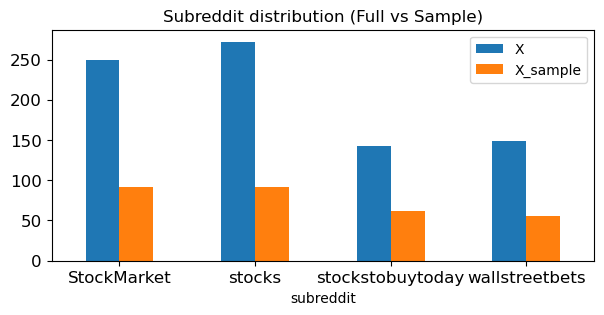

In [22]:
# Count subreddit distribution
x_counts = X['subreddit'].value_counts()
x_sample_counts = X_sample['subreddit'].value_counts()


X_and_Xsamp = pd.DataFrame({
    "X": x_counts,
    "X_sample": x_sample_counts
})

# Plot
X_and_Xsamp.plot(kind="bar", figsize=(7,3), rot=0, fontsize=12)
plt.title("Subreddit distribution (Full vs Sample)")
plt.ylim(0, max(x_counts.max(), x_sample_counts.max()) + 15)
plt.show()

In [23]:
X['unigrams'] = X['text'].apply(lambda x: dmh.tokenize_text(x))
X[0:4]["unigrams"]

0                                 [Calls, on, retards]
1    [Stunt, as, in, like, why, did, they, even, ma...
2          [Seeing, lots, of, red, in, the, ticker, .]
3    [Vision, Marine, Technologies, Inc., is, rewri...
Name: unigrams, dtype: object

In [24]:
list(X[0:2]['unigrams'])

[['Calls', 'on', 'retards'],
 ['Stunt',
  'as',
  'in',
  'like',
  'why',
  'did',
  'they',
  'even',
  'make',
  'a',
  'big',
  'deal',
  'about',
  'starting',
  'it',
  'in',
  'the',
  'first',
  'place',
  '?',
  'No',
  'company',
  'should',
  'ever',
  'talk',
  'about',
  'politics',
  'ever',
  '.']]

In [25]:
#Assign to text variablee
text_data = X["text"].fillna("").astype(str)

In [26]:
# tokenize text into words,  and so on ... ...
count_vect = CountVectorizer(stop_words='english')
analyze = count_vect.build_analyzer()

# Learn vocab + transform text
X_counts = count_vect.fit_transform(text_data)

# Vocabulary
vocab = count_vect.get_feature_names_out()

# Term frequencies (sum over all docs)
counts = np.asarray(X_counts.sum(axis=0)).ravel()

In [27]:
count_vect.get_feature_names_out()[555]

'bought'

In [28]:
analyze(X['text'].iloc[1])

['stunt',
 'like',
 'did',
 'make',
 'big',
 'deal',
 'starting',
 'place',
 'company',
 'talk',
 'politics']

In [29]:
# convert from sparse array to normal array
X_counts[0:5, 0:100].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [30]:
mask = X_counts[4].indices
print("Indices with 1s:", mask)
print("Words:", [count_vect.get_feature_names_out()[i] for i in mask])

Indices with 1s: [1105 3159 3627]
Words: ['didn', 'say', 'thank']


doc_idx: [654, 114, 25, 759, 281, 250, 228, 142, 754, 104, 692, 758, 558, 89, 604]
term_idx: [2064, 3739, 2173, 2284, 743, 3636, 2648, 1636, 1641, 2394, 3593, 2263, 3664, 3926, 1160]


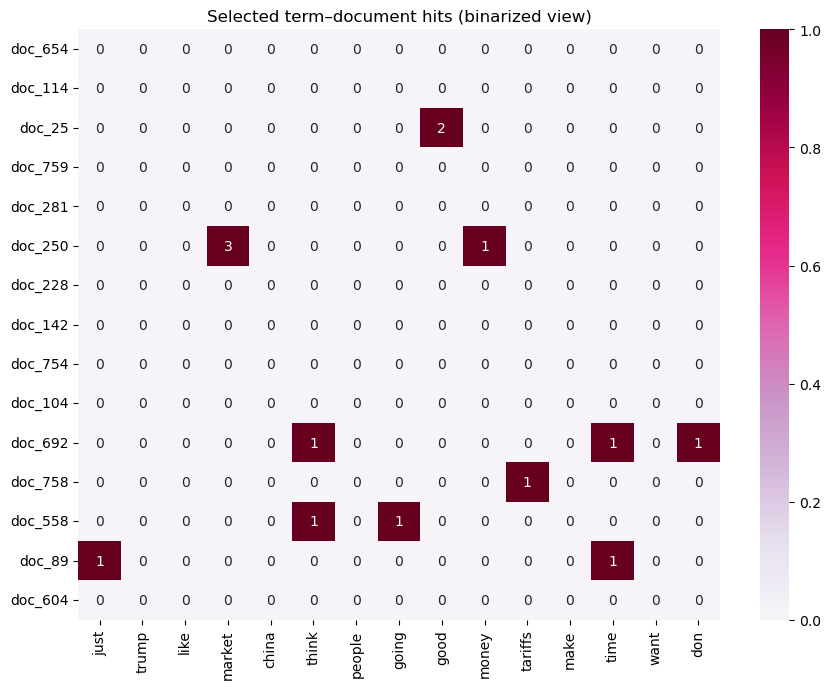

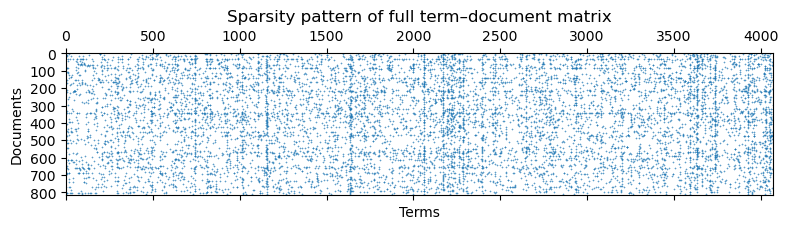

In [31]:
# --- pick 15 documents ---
random.seed(42)
n_docs = X_counts.shape[0]
doc_idx = random.sample(range(n_docs), 15)

# --- pick 15 terms with total frequency > 50 ---
term_frequencies = np.asarray(X_counts.sum(axis=0)).ravel()
term_idx = [i for i, f in enumerate(term_frequencies) if f > 50][:15]
if len(term_idx) < 15:
    #take top-15 by frequency
    term_idx = np.argsort(-term_frequencies)[:15].tolist()

print("doc_idx:", doc_idx)
print("term_idx:", term_idx)

# --- i making the labels here ---
feature_names = count_vect.get_feature_names_out()
plot_x = [f"{t}" for t in feature_names[term_idx]]
plot_y = [f"doc_{i}" for i in doc_idx]

# --- slice the sparse matrix and convert to dense for plotting ---
plot_z = X_counts[np.ix_(doc_idx, term_idx)].toarray()

df_todraw = pd.DataFrame(plot_z, columns=plot_x, index=plot_y)
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_todraw, cmap="PuRd", vmin=0, vmax=1, annot=True)
plt.title("Selected term–document hits (binarized view)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.spy(X_counts, markersize=0.2)
plt.title("Sparsity pattern of full term–document matrix")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.tight_layout()
plt.show()

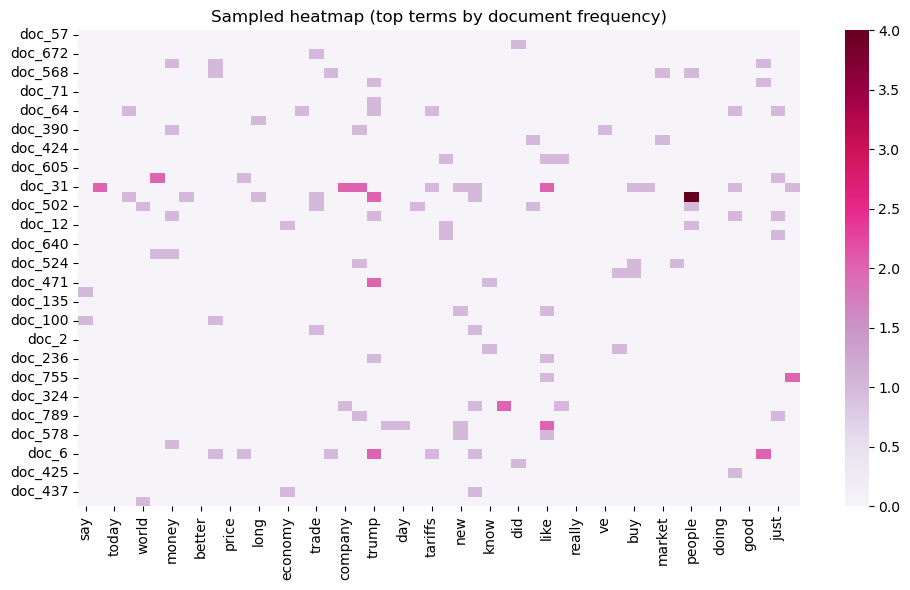

In [32]:
rng = np.random.default_rng(0)

n_docs  = 50
n_terms = 50

doc_idx  = rng.choice(X_counts.shape[0], size=n_docs, replace=False)

df_counts = np.asarray((X_counts > 0).sum(axis=0)).ravel()
term_idx = np.argpartition(df_counts, -n_terms)[-n_terms:]

sub = X_counts[doc_idx][:, term_idx].toarray()

feature_names = count_vect.get_feature_names_out()
cols = [feature_names[i] for i in term_idx]
rows = [f"doc_{i}" for i in doc_idx]

plt.figure(figsize=(10,6))
ax = sns.heatmap(pd.DataFrame(sub, index=rows, columns=cols),
                 cmap="PuRd", vmin=0, vmax=sub.max() or 1, annot=False)
ax.set_title("Sampled heatmap (top terms by document frequency)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
# Frequency table
freq_df = pd.DataFrame({"word": vocab, "count": counts}).sort_values("count", ascending=False).reset_index(drop=True)

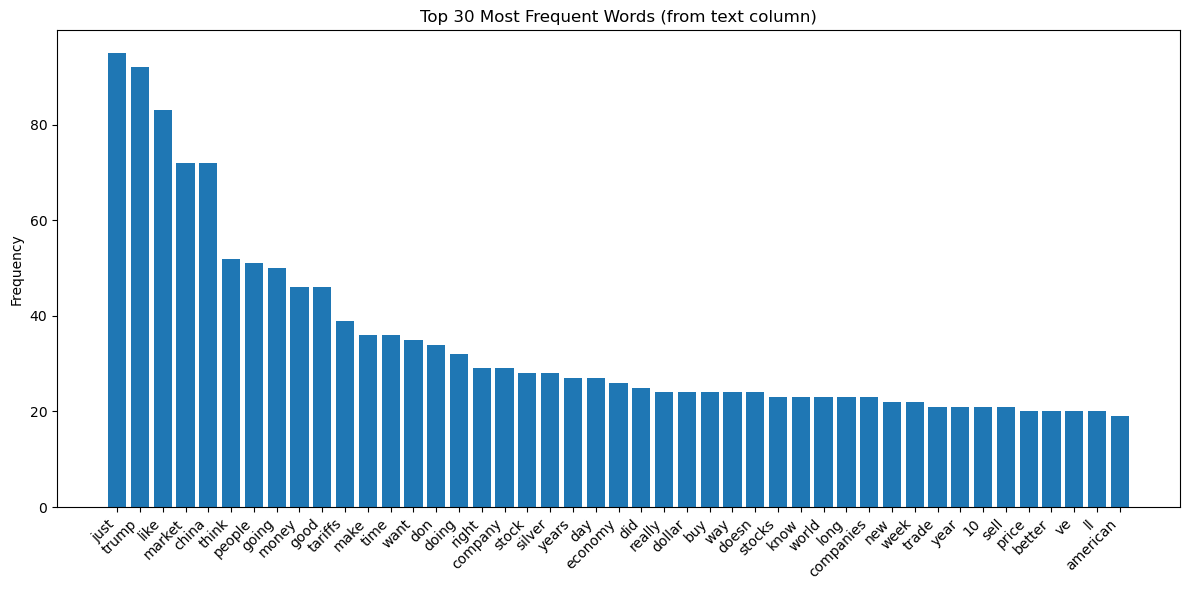

In [34]:
# --- Top 30 words bar chart ---
top_df = freq_df.head(45)
plt.figure(figsize=(12, 6))
plt.bar(top_df["word"], top_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 30 Most Frequent Words (from text column)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [35]:
# --- Rank–frequency plots ---
y = freq_df["count"].values
x = range(1, len(y) + 1)

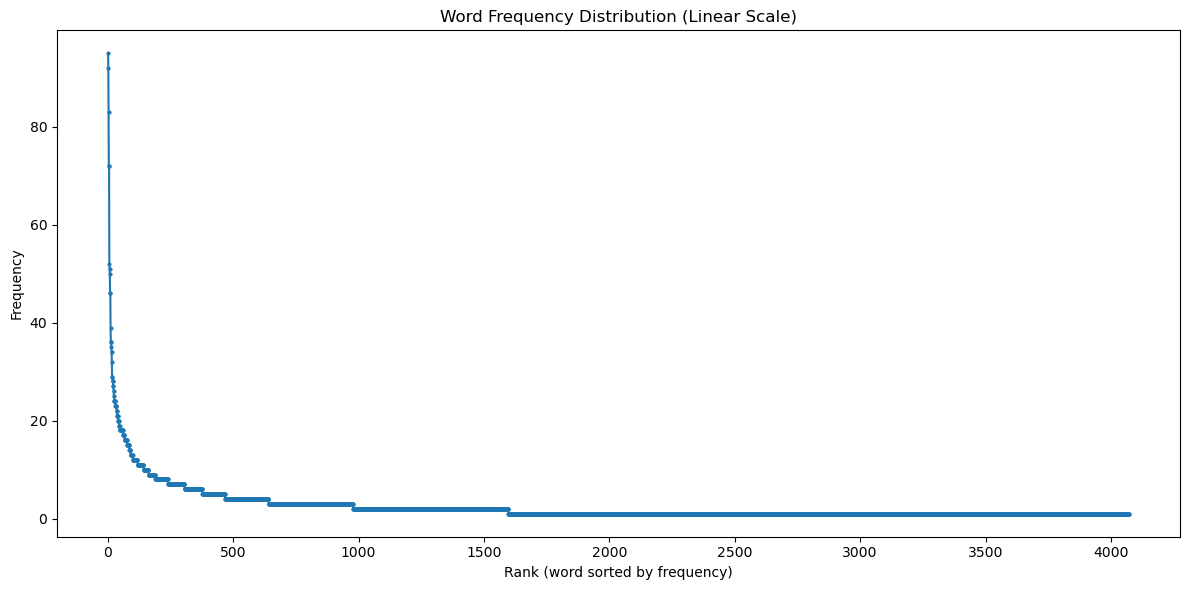

In [36]:
# Linear scale
plt.figure(figsize=(12, 6))
plt.plot(x, y, marker="o", linestyle="-", markersize=2)
plt.title("Word Frequency Distribution (Linear Scale)")
plt.xlabel("Rank (word sorted by frequency)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

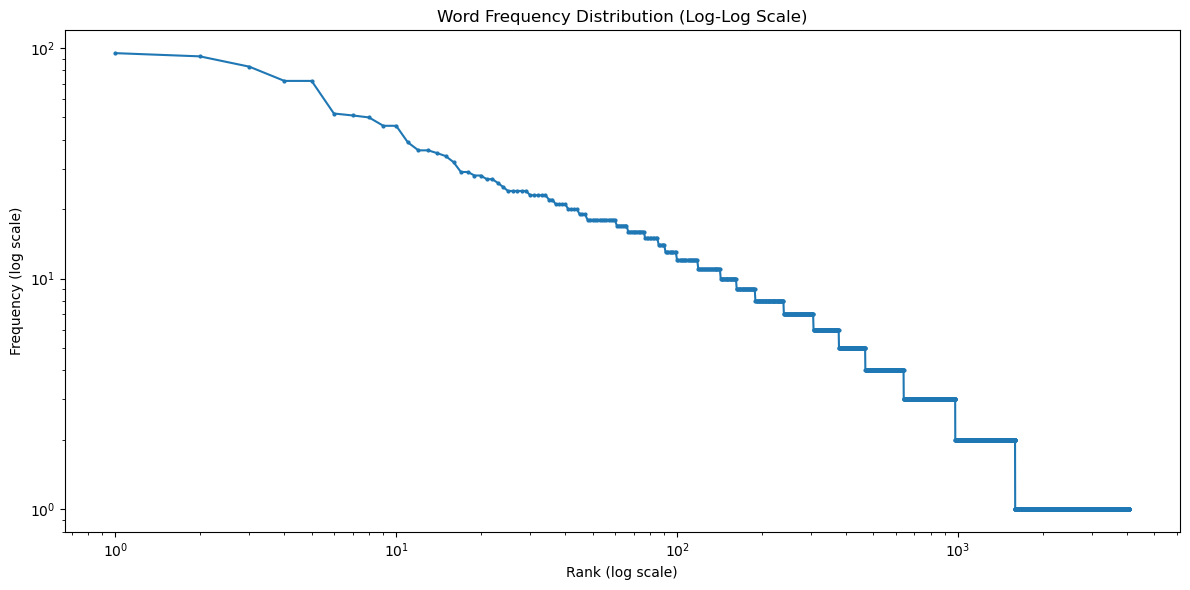

In [37]:
# Log–log scale
plt.figure(figsize=(12, 6))
plt.loglog(x, y, marker="o", linestyle="-", markersize=2)
plt.title("Word Frequency Distribution (Log-Log Scale)")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()


### Here Below are a few different meaningful new data visualizations

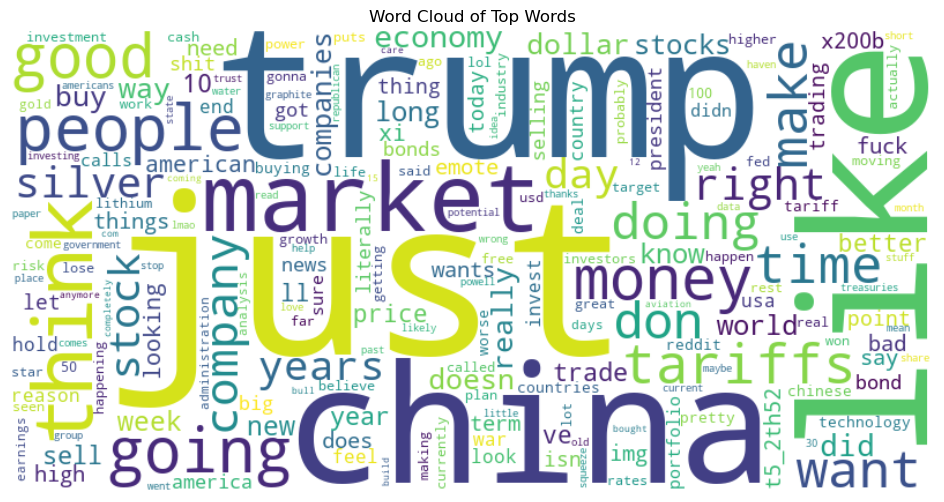

In [38]:
word_freq = dict(zip(vocab, counts))

# Generate word cloud
wc = WordCloud(width=800, height=400,
               background_color="white",
               colormap="viridis",
               max_words=200).generate_from_frequencies(word_freq)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Top Words")
plt.show()

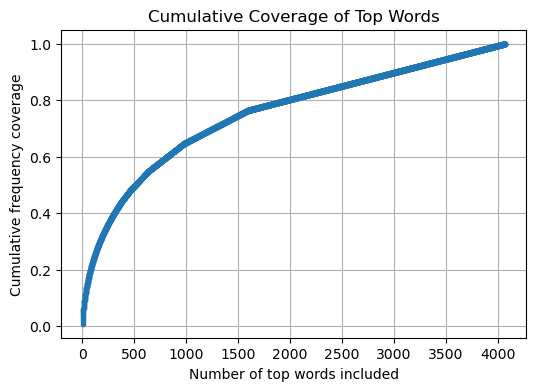

In [39]:
# Sort word counts in descending order
sorted_counts = np.sort(counts)[::-1]

# Ranks for each word (1, 2, 3, …)
ranks = np.arange(1, len(sorted_counts)+1)

# Cumulative frequency (normalized)
cum_freq = np.cumsum(sorted_counts) / np.sum(sorted_counts)

# Plot
plt.figure(figsize=(6,4))
plt.plot(ranks, cum_freq, marker=".")
plt.xlabel("Number of top words included")
plt.ylabel("Cumulative frequency coverage")
plt.title("Cumulative Coverage of Top Words")
plt.grid(True)
plt.show()

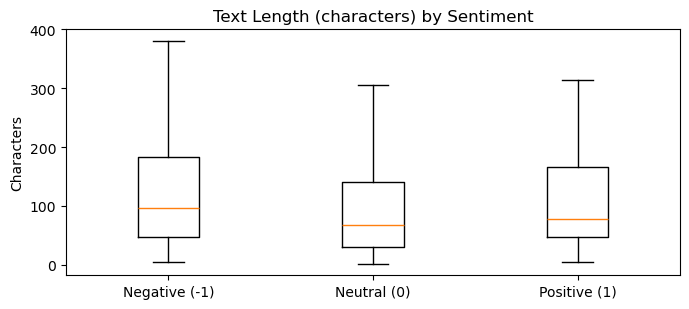

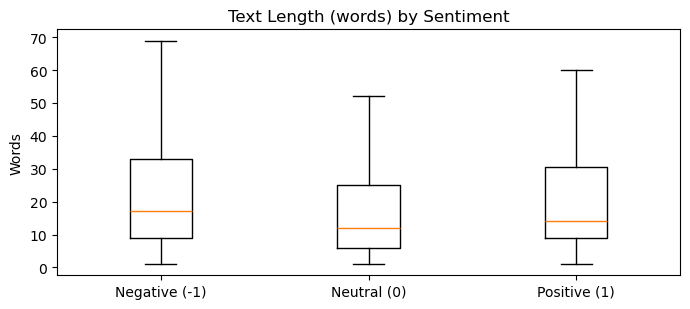

In [40]:
X_len = X[['text','label']].dropna().copy()
X_len['len_chars'] = X_len['text'].astype(str).str.len()
X_len['len_words'] = X_len['text'].astype(str).str.split().str.len()

# Boxplot by label (characters)
plt.figure(figsize=(7,3.2))
data = [X_len.loc[X_len['label']==k, 'len_chars'] for k in [-1.0, 0.0, 1.0]]
plt.boxplot(data, tick_labels=["Negative (-1)", "Neutral (0)", "Positive (1)"], showfliers=False)
plt.title("Text Length (characters) by Sentiment")
plt.ylabel("Characters")
plt.tight_layout()
plt.show()

# Boxplot by label (words)
plt.figure(figsize=(7,3.2))
data_w = [X_len.loc[X_len['label']==k, 'len_words'] for k in [-1.0, 0.0, 1.0]]
plt.boxplot(data_w, tick_labels=["Negative (-1)", "Neutral (0)", "Positive (1)"], showfliers=False)
plt.title("Text Length (words) by Sentiment")
plt.ylabel("Words")
plt.tight_layout()
plt.show()

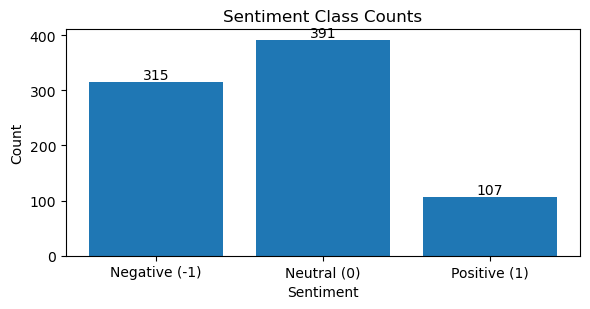

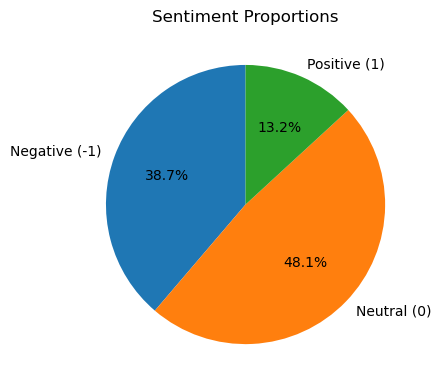

In [41]:
#Class balance (counts & proportions)
labels = X['label'].astype(float)  # ensure numeric -1,0,1
counts = labels.value_counts().sort_index()  # order: -1, 0, 1
order = [-1.0, 0.0, 1.0]
names = { -1.0: "Negative (-1)", 0.0: "Neutral (0)", 1.0: "Positive (1)" }
vals = [counts.get(i, 0) for i in order]

plt.figure(figsize=(6,3.2))
plt.bar([names[i] for i in order], vals)
plt.title("Sentiment Class Counts")
plt.xlabel("Sentiment")
plt.ylabel("Count")
for i,v in enumerate(vals):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4.5,4.5))
plt.pie(vals, labels=[names[i] for i in order], autopct="%.1f%%", startangle=90)
plt.title("Sentiment Proportions")
plt.tight_layout()
plt.show()

# Phase 2

### Finding frequent patterns

In [42]:
# Create a single term-document frequency DataFrame for all documents, with subreddit as a column

texts = X['text'].fillna("").astype(str)
subreddits = X['subreddit']
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(texts)
tdf = pd.DataFrame(X_counts.toarray(), columns=vectorizer.get_feature_names_out(), index=X.index)
tdf['subreddit'] = subreddits.values
display(tdf)

,00,000,01378,02,027,03,06,08,10,100,...,yippee,yo,young,youtube,yoyo,yup,zero,zgld,zone,zsil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
842,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
845,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# --- Filtering top 5% and bottom 1% frequent words ---

# Calculate term frequencies
term_freq = tdf.drop(columns=['subreddit']).sum(axis=0)

# Determine thresholds
num_terms = len(term_freq)
top_n = int(np.ceil(num_terms * 0.05))  # top 5%
bottom_n = int(np.ceil(num_terms * 0.01))  # bottom 1%

# Get indices for filtering
sorted_terms = term_freq.sort_values(ascending=False)
top_terms = sorted_terms.index[:top_n]
bottom_terms = sorted_terms.index[-bottom_n:]

# Combine terms to filter out
filter_terms = set(top_terms).union(set(bottom_terms))

# Show the words to be filtered (top and bottom)
print(f"Top 5% most frequent words (to filter): {list(top_terms)}")
print(f"Bottom 1% least frequent words (to filter): {list(bottom_terms)}")
print(f"Total words to filter: {len(filter_terms)}")

# Filter the term-document frequency DataFrame
tdf_filtered = tdf.drop(columns=filter_terms)

display(tdf_filtered)

Top 5% most frequent words (to filter): ['just', 'trump', 'like', 'china', 'market', 'think', 'people', 'going', 'good', 'money', 'tariffs', 'time', 'make', 'want', 'don', 'doing', 'right', 'company', 'silver', 'stock', 'day', 'years', 'economy', 'did', 'way', 'buy', 'dollar', 'doesn', 'really', 'stocks', 'know', 'world', 'companies', 'long', 'new', 'week', 'sell', 'trade', '10', 'year', 've', 'll', 'price', 'better', 'xi', 'looking', 'american', 'wants', 'say', 't5_2th52', 'things', 'emote', 'img', 'x200b', 'fuck', 'need', 'high', 'bad', 'does', 'term', 'today', 'let', 'point', 'trading', 'thing', 'isn', 'bonds', 'bond', 'shit', 'got', 'president', 'big', 'literally', 'america', 'selling', 'news', 'look', 'war', 'reason', 'invest', 'country', 'hold', 'end', 'feel', 'usa', 'didn', 'calls', 'technology', 'portfolio', 'sure', 'buying', 'reddit', 'chinese', 'come', 'worse', 'deal', 'tariff', 'pretty', 'countries', 'real', 'work', 'currently', 'ago', '50', 'usd', 'far', 'power', 'target', 

,00,000,01378,02,027,03,06,08,1000,10000,...,yikes,yippee,yo,young,youtube,yoyo,yup,zero,zgld,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
842,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
843,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
845,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


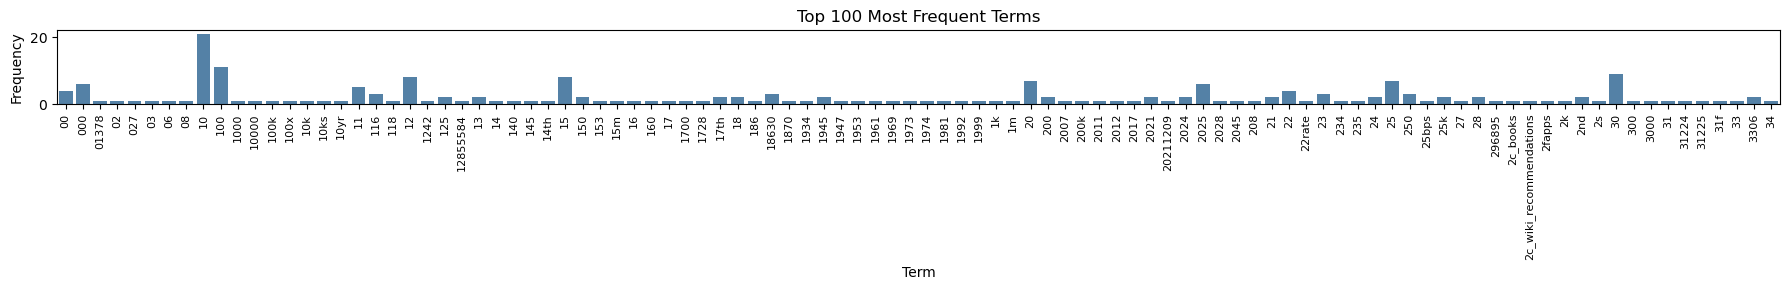

In [56]:
N = 100  # Show top 100 terms
plt.figure(figsize=(18, 3))
sns.barplot(x=term_freq.index[:N], y=term_freq.values[:N], color='steelblue')
plt.xticks(rotation=90, fontsize=8)
plt.title(f'Top {N} Most Frequent Terms')
plt.xlabel('Term')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [45]:
# Convert filtered term-document matrix to transactional database format for PAMI
from PAMI.extras.convert.DF2DB import DF2DB

# Remove the 'subreddit' column for transaction conversion, but keep it for grouping
cols = [col for col in tdf_filtered.columns if col != 'subreddit']

# Group by subreddit and export a transactional CSV for each subreddit
for subreddit, group in tdf_filtered.groupby('subreddit'):
    # Drop the subreddit column for conversion
    group_nosub = group[cols]
    # Binarize: set all nonzero counts to 1 (word present) using vectorized ops
    group_bin = group_nosub.gt(0).astype(int)
    # Convert to transactional database (each row: list of present words)
    transactions = group_bin.apply(lambda row: [col for col, val in row.items() if val == 1], axis=1)
    out_path = f"td_freq_db_{subreddit}.csv"
    transactions.to_csv(out_path, index=False, header=False)
    print(f"Exported transactional DB for subreddit '{subreddit}' to {out_path}")

Exported transactional DB for subreddit 'StockMarket' to td_freq_db_StockMarket.csv
Exported transactional DB for subreddit 'stocks' to td_freq_db_stocks.csv
Exported transactional DB for subreddit 'stockstobuytoday' to td_freq_db_stockstobuytoday.csv
Exported transactional DB for subreddit 'wallstreetbets' to td_freq_db_wallstreetbets.csv
Exported transactional DB for subreddit 'wallstreetbets' to td_freq_db_wallstreetbets.csv



--- Stats for td_freq_db_stockstobuytoday.csv ---
Database Size (Transactions): 142
Number of Items: 1271
Min Transaction Size: 1
Avg Transaction Size: 10.68
Max Transaction Size: 161
Std Dev Transaction Size: 20.65
Variance Transaction Size: 426.50
Sparsity: 0.9916


<Figure size 1800x300 with 0 Axes>

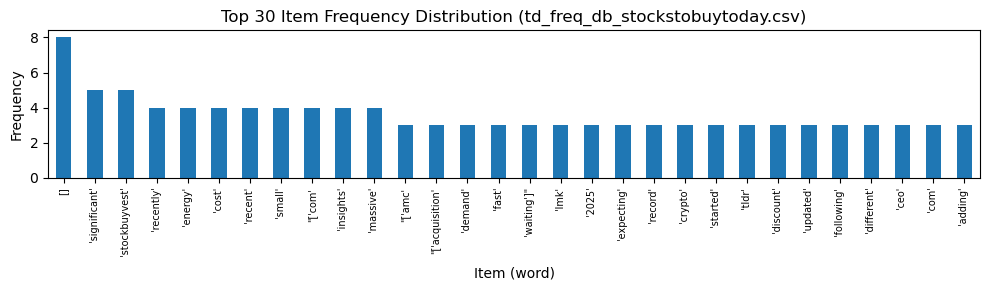

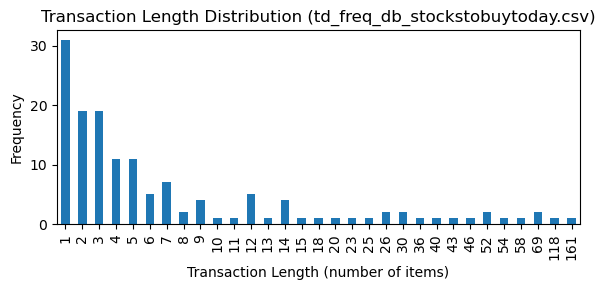


--- Stats for td_freq_db_stocks.csv ---
Database Size (Transactions): 272
Number of Items: 2069
Min Transaction Size: 1
Avg Transaction Size: 9.76
Max Transaction Size: 111
Std Dev Transaction Size: 12.08
Variance Transaction Size: 145.97
Sparsity: 0.9953


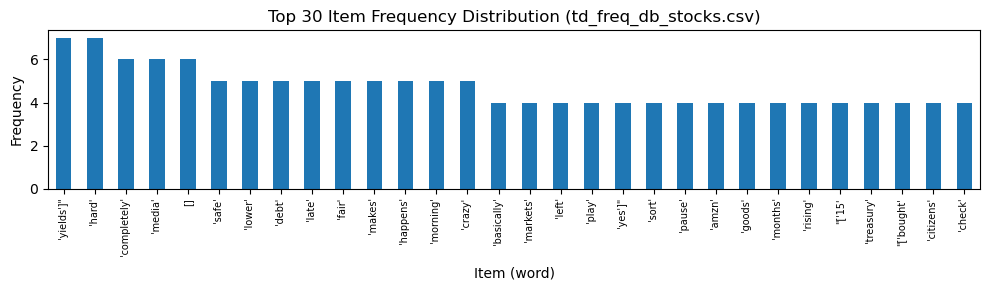

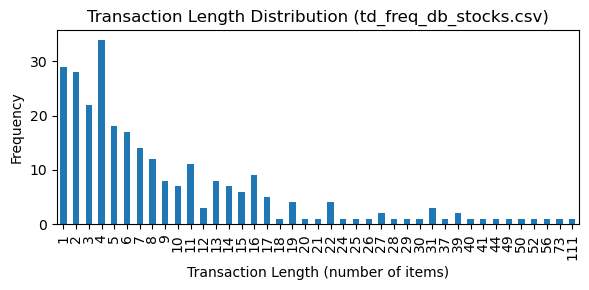


--- Stats for td_freq_db_wallstreetbets.csv ---
Database Size (Transactions): 149
Number of Items: 701
Min Transaction Size: 1
Avg Transaction Size: 5.20
Max Transaction Size: 42
Std Dev Transaction Size: 5.76
Variance Transaction Size: 33.18
Sparsity: 0.9926


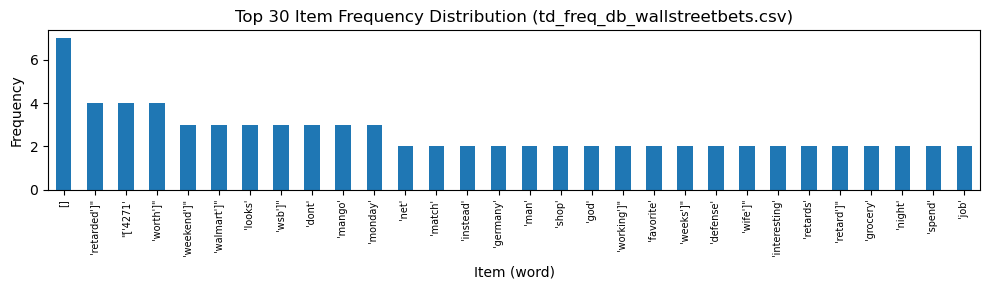

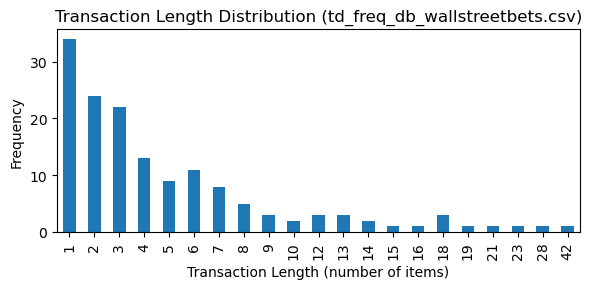


--- Stats for td_freq_db_StockMarket.csv ---
Database Size (Transactions): 250
Number of Items: 1322
Min Transaction Size: 1
Avg Transaction Size: 6.28
Max Transaction Size: 100
Std Dev Transaction Size: 8.21
Variance Transaction Size: 67.39
Sparsity: 0.9952


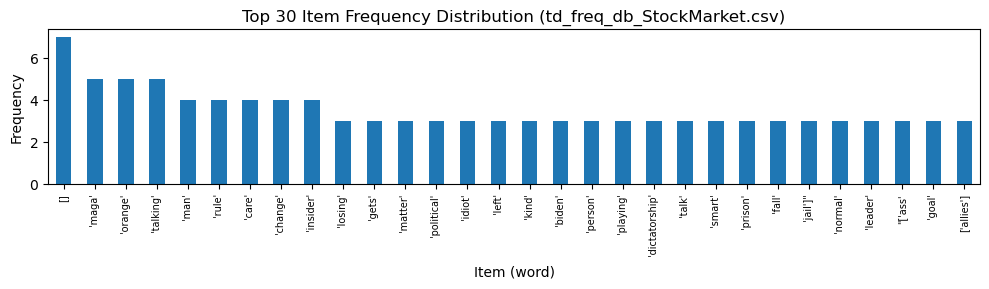

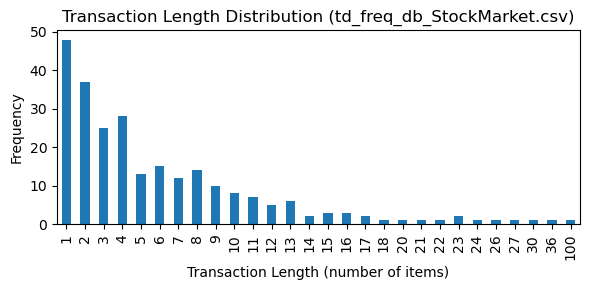

In [ ]:
# Analyze stats and visualize transactional databases for each subreddit
subreddit_names = set(X['subreddit'].unique())
csv_files = [
    f for f in os.listdir('.')
    if f.startswith('td_freq_db_') and f.endswith('.csv') and f[11:-4] in subreddit_names
]

for csv_file in csv_files:
    print(f"\n--- Stats for {csv_file} ---")
    # Read each line as a transaction (comma-separated items)
    with open(csv_file, 'r') as f:
        transaction_lists = [line.strip().split(',') for line in f if line.strip()]
    all_items = [item for trans in transaction_lists for item in trans if item]
    unique_items = set(all_items)
    trans_lengths = [len(trans) for trans in transaction_lists]

    # Stats
    num_transactions = len(transaction_lists)
    num_items = len(unique_items)
    min_trans_size = min(trans_lengths) if trans_lengths else 0
    avg_trans_size = np.mean(trans_lengths) if trans_lengths else 0
    max_trans_size = max(trans_lengths) if trans_lengths else 0
    std_trans_size = np.std(trans_lengths) if trans_lengths else 0
    var_trans_size = np.var(trans_lengths) if trans_lengths else 0
    total_nonzero = sum(trans_lengths)
    sparsity = 1 - (total_nonzero / (num_transactions * num_items)) if num_items > 0 and num_transactions > 0 else np.nan

    print(f"Database Size (Transactions): {num_transactions}")
    print(f"Number of Items: {num_items}")
    print(f"Min Transaction Size: {min_trans_size}")
    print(f"Avg Transaction Size: {avg_trans_size:.2f}")
    print(f"Max Transaction Size: {max_trans_size}")
    print(f"Std Dev Transaction Size: {std_trans_size:.2f}")
    print(f"Variance Transaction Size: {var_trans_size:.2f}")
    print(f"Sparsity: {sparsity:.4f}")

    # Item frequency distribution (top 30 only)
    item_freq = pd.Series(all_items).value_counts()
    top_n = 30
    plt.figure(figsize=(10,3))
    item_freq.head(top_n).plot(kind='bar')
    plt.title(f'Top {top_n} Item Frequency Distribution ({csv_file})')
    plt.xlabel('Item (word)')
    plt.ylabel('Frequency')
    plt.xticks(rotation=90, fontsize=7)
    plt.tight_layout()
    plt.show()

    # Transaction length distribution
    plt.figure(figsize=(6,3))
    pd.Series(trans_lengths).value_counts().sort_index().plot(kind='bar')
    plt.title(f'Transaction Length Distribution ({csv_file})')
    plt.xlabel('Transaction Length (number of items)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

In [57]:
print("""
- Number of Transactions - Reflects the number of documents per category (subreddit).
- Number of Items - Indicates the vocabulary size (unique words) in each category.
- Transaction Size - Shows how many words typically appear in each document.
- Sparsity - High sparsity means most words do not appear in most documents
""")


- Number of Transactions - Reflects the number of documents per category (subreddit).
- Number of Items - Indicates the vocabulary size (unique words) in each category.
- Transaction Size - Shows how many words typically appear in each document.
- Sparsity - High sparsity means most words do not appear in most documents



In [ ]:

from PAMI.frequentPattern.basic import FPGrowth as alg

minSup = 25

# Find subreddit-specific transactional CSVs
subreddit_names = set(X["subreddit"].unique())
csv_files = [
    f for f in os.listdir(".")
    if f.startswith("td_freq_db_") and f.endswith(".csv") and f[11:-4] in subreddit_names
]

for csv_file in csv_files:
    print(f"\n--- FPGrowth Results for {csv_file} (minSup={minSup}) ---")

    # Run FPGrowth
    obj = alg.FPGrowth(iFile=csv_file, minSup=minSup)
    obj.mine()
    patterns_df = obj.getPatternsAsDataFrame()

    print(f"Total patterns: {len(patterns_df)}")
    print(f"Runtime: {obj.getRuntime()}s")

    if patterns_df.empty:
        print("No frequent patterns found.")
        continue

    # Identify pattern and support columns
    cols_lower = {c.lower(): c for c in patterns_df.columns}
    support_col = cols_lower.get("support", cols_lower.get("sup"))
    pattern_col = cols_lower.get("patterns", cols_lower.get("pattern", cols_lower.get("itemset")))

    # Display top 10 patterns
    if support_col:
        top_patterns = patterns_df.sort_values(by=support_col, ascending=False).head(10)
        for _, row in top_patterns.iterrows():
            patt = row.get(pattern_col, "N/A")
            supp = row[support_col]
            print(f"Pattern: {patt}, Support: {supp}")
    else:
        print("No support column found. Showing first 10 rows:")
        print(patterns_df.head(10))


--- FPGrowth Results for td_freq_db_stockstobuytoday.csv (minSup=25) ---
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total patterns: 0
Runtime: 0.0008838176727294922s
No frequent patterns found.

--- FPGrowth Results for td_freq_db_stocks.csv (minSup=25) ---
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total patterns: 0
Runtime: 0.0004570484161376953s
No frequent patterns found.

--- FPGrowth Results for td_freq_db_wallstreetbets.csv (minSup=25) ---
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total patterns: 0
Runtime: 0.0002410411834716797s
No frequent patterns found.

--- FPGrowth Results for td_freq_db_StockMarket.csv (minSup=25) ---
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Total patterns: 0
Runtime: 0.00032782554626464844s
No frequent patterns found.


In [48]:
# === Extract Frequent Patterns per Subreddit and Add as Features ===

from PAMI.frequentPattern.basic import FPGrowth as alg

# Load patterns per subreddit
pattern_dict = defaultdict(set)
pattern_support = defaultdict(dict)

subreddit_names = set(X["subreddit"].unique())
csv_files = [
    f for f in os.listdir(".")
    if f.startswith("td_freq_db_") and f.endswith(".csv") and f[11:-4] in subreddit_names
]

for csv_file in csv_files:
    subreddit = csv_file[11:-4]
    obj = alg.FPGrowth(iFile=csv_file, minSup=2)
    obj.mine()
    df = obj.getPatternsAsDataFrame()

    # Detect columns
    cols = {c.lower(): c for c in df.columns}
    patt_col = cols.get("patterns") or cols.get("pattern") or cols.get("itemset")
    sup_col = cols.get("support") or cols.get("sup")
    if not (patt_col and sup_col):
        print(f"Missing pattern/support columns for {subreddit}")
        continue

    for _, row in df.iterrows():
        patt = row[patt_col]
        if isinstance(patt, str):
            patt = tuple(sorted(patt.strip("[]").replace("'", "").replace(" ", "").split(",")))
        elif isinstance(patt, (list, tuple, set)):
            patt = tuple(sorted(patt))
        else:
            continue
        pattern_dict[subreddit].add(patt)
        pattern_support[subreddit][patt] = row[sup_col]

# Find unique patterns per subreddit
all_patterns = set().union(*pattern_dict.values())
unique_patterns = {
    s: pattern_dict[s] - set().union(*(pattern_dict[o] for o in pattern_dict if o != s))
    for s in pattern_dict
}

# Add unique pattern features to DataFrame
for s, patterns in unique_patterns.items():
    for patt in patterns:
        if not patt or patt == ("",):
            continue
        colname = f"pat_{s}_" + "_".join(patt)
        X[colname] = X.apply(
            lambda row: int(row["subreddit"] == s and all(w in row["text"] for w in patt)),
            axis=1,
        )

# Show summary
added_cols = [c for c in X.columns if c.startswith("pat_")]
print(f"Added {len(added_cols)} unique pattern features to X.")
print(X[added_cols].sum().sort_values(ascending=False).head(20))

Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Frequent patterns were generated successfully using frequentPatternGrowth algorithm
Added 6 unique pattern features to X.
pat_StockMarket_allies          6
pat_StockMarket_matter          6
pat_StockMarket_dump            5
pat_StockMarket_bullshit        4
pat_StockMarket_bob             1
pat_StockMarket_"[ass_kiss]"    0
dtype: int64


### Dimensionality Reduction

In [ ]:
# === TruncatedSVD (2D projection for sparse term–document matrix) ===
# Ensure term–document matrix exists
if "X_counts" not in globals():
    if "X" not in globals():
        X = pd.read_csv("newdataset/Reddit-stock-sentiment.csv", usecols=["text", "subreddit", "label"])
    texts = X["text"].fillna("").astype(str)
    X_counts = CountVectorizer(stop_words="english").fit_transform(texts)

# Compute 2D TruncatedSVD (PCA-like for sparse data)
svd = TruncatedSVD(n_components=2, random_state=42)
proj2 = svd.fit_transform(X_counts)
explained_var = svd.explained_variance_ratio_.sum()

# Package into DataFrame and attach metadata
pca2d_df = pd.DataFrame(proj2, columns=["PC1", "PC2"])
if {"label", "subreddit"}.issubset(X.columns):
    meta = X[["label", "subreddit"]].reset_index(drop=True)
    pca2d_df = pd.concat([pca2d_df, meta], axis=1)

# Display summary
print(f"2D SVD explained variance ratio (sum): {explained_var:.4f}")
print(f"Projection shape: {proj2.shape}")
pca2d_df.head()

2D SVD explained variance ratio (sum): 0.1001
Projection shape: (813, 2)


,PC1,PC2,label,subreddit
0,0.005153,0.015596,-1.0,wallstreetbets
1,0.163016,0.678986,0.0,wallstreetbets
2,0.008770,0.080189,0.0,StockMarket
3,1.299400,1.927485,1.0,stockstobuytoday
4,0.005054,0.043936,-1.0,StockMarket


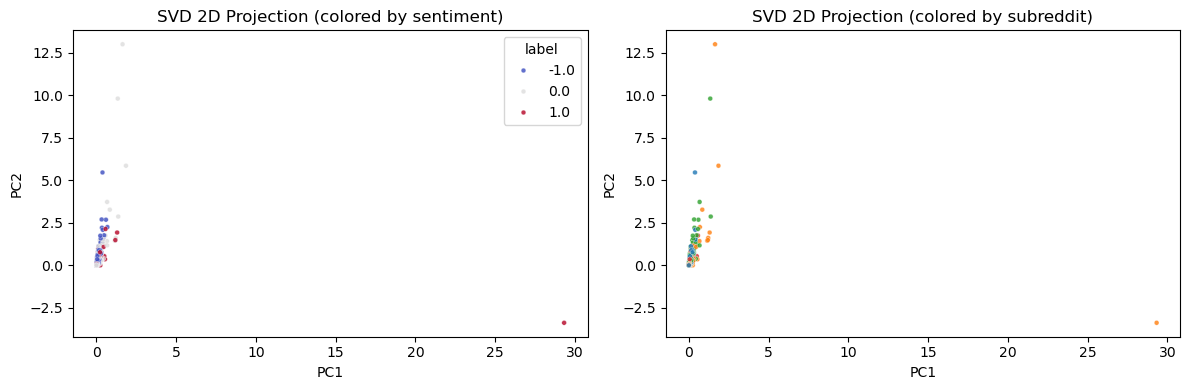

In [ ]:
# 2D scatter plots of projections
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Colored by sentiment label if available
if 'label' in pca2d_df.columns:
    sns.scatterplot(
        data=pca2d_df.sample(min(3000, len(pca2d_df)), random_state=42),
        x='PC1', y='PC2', hue='label', palette='coolwarm', s=12, ax=ax[0], alpha=0.8
    )
    ax[0].set_title('SVD 2D Projection (colored by sentiment)')
else:
    ax[0].scatter(pca2d_df['PC1'], pca2d_df['PC2'], s=8, alpha=0.7)
    ax[0].set_title('SVD 2D Projection')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')

# Colored by subreddit if available
if 'subreddit' in pca2d_df.columns:
    sns.scatterplot(
        data=pca2d_df.sample(min(3000, len(pca2d_df)), random_state=42),
        x='PC1', y='PC2', hue='subreddit', s=12, ax=ax[1], alpha=0.8, legend=False
    )
    ax[1].set_title('SVD 2D Projection (colored by subreddit)')
else:
    ax[1].scatter(pca2d_df['PC1'], pca2d_df['PC2'], s=8, alpha=0.7)
    ax[1].set_title('SVD 2D Projection')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [51]:

# Ensure term–document matrix exists
if "X_counts" not in globals():
    texts = X["text"].fillna("").astype(str)
    X_counts = CountVectorizer(stop_words="english").fit_transform(texts)

# Optional: pre-reduce dimensions with SVD if feature space is very large
X_for_umap = (
    TruncatedSVD(n_components=100, random_state=42).fit_transform(X_counts)
    if X_counts.shape[1] > 5000
    else X_counts
)

# Compute 2D UMAP embedding
umap_model = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
umap2d = umap_model.fit_transform(X_for_umap)

# Create DataFrame and attach metadata
umap2d_df = pd.DataFrame(umap2d, columns=["U1", "U2"])
if {"label", "subreddit"}.issubset(X.columns):
    meta = X[["label", "subreddit"]].reset_index(drop=True)
    umap2d_df = pd.concat([umap2d_df, meta], axis=1)

# Display summary
print(f"UMAP 2D shape: {umap2d_df.shape}")
umap2d_df.head()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D shape: (813, 4)


,U1,U2,label,subreddit
0,-7.275311,-15.190908,-1.0,wallstreetbets
1,-4.795765,-17.003855,0.0,wallstreetbets
2,-8.016109,-16.560755,0.0,StockMarket
3,-6.551517,-16.070587,1.0,stockstobuytoday
4,-8.147202,-16.848509,-1.0,StockMarket


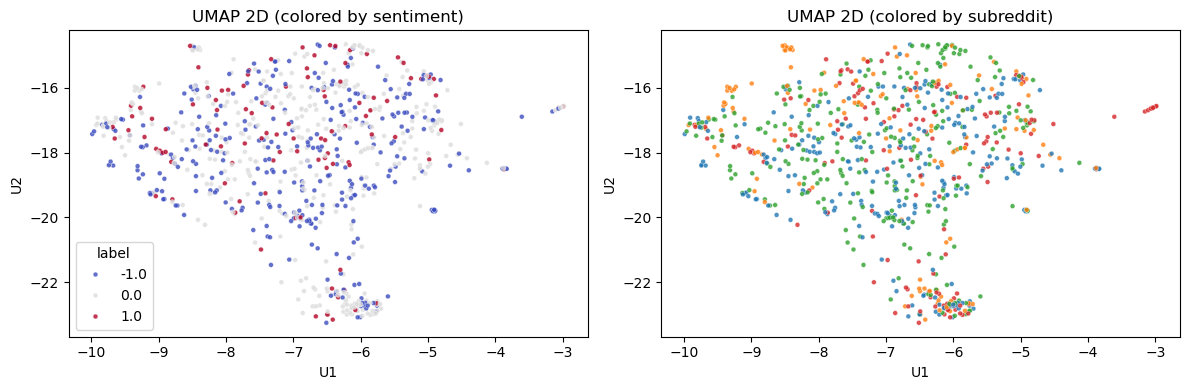

In [52]:
# 2D UMAP plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Colored by sentiment label
if 'label' in umap2d_df.columns:
    sns.scatterplot(
        data=umap2d_df.sample(min(3000, len(umap2d_df)), random_state=42),
        x='U1', y='U2', hue='label', palette='coolwarm', s=12, ax=ax[0], alpha=0.8
    )
    ax[0].set_title('UMAP 2D (colored by sentiment)')
else:
    ax[0].scatter(umap2d_df['U1'], umap2d_df['U2'], s=8, alpha=0.7)
    ax[0].set_title('UMAP 2D')
ax[0].set_xlabel('U1')
ax[0].set_ylabel('U2')

# Colored by subreddit
if 'subreddit' in umap2d_df.columns:
    sns.scatterplot(
        data=umap2d_df.sample(min(3000, len(umap2d_df)), random_state=42),
        x='U1', y='U2', hue='subreddit', s=12, ax=ax[1], alpha=0.8, legend=False
    )
    ax[1].set_title('UMAP 2D (colored by subreddit)')
else:
    ax[1].scatter(umap2d_df['U1'], umap2d_df['U2'], s=8, alpha=0.7)
    ax[1].set_title('UMAP 2D')
ax[1].set_xlabel('U1')
ax[1].set_ylabel('U2')

plt.tight_layout()
plt.show()

In [ ]:
# Compute 2D t-SNE with SVD pre-reduction

# Ensure X_counts exists; rebuild if needed
try:
    _ = X_counts  
except NameError:
    from sklearn.feature_extraction.text import CountVectorizer
    texts = X['text'].fillna('').astype(str)
    cv = CountVectorizer(stop_words='english')
    X_counts = cv.fit_transform(texts)

# Pre-reduce to 50 dims for t-SNE speed and stability
svd_tsne = TruncatedSVD(n_components=50, random_state=42)
X_red = svd_tsne.fit_transform(X_counts)

# t-SNE 2D
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', n_iter=1000, init='pca', random_state=42)
emb2 = tsne.fit_transform(X_red)

# Package with metadata
tsne2d_df = pd.DataFrame(emb2, columns=['T1', 'T2'])
if 'X' in globals():
    meta = X[['label', 'subreddit']].reset_index(drop=True)
    tsne2d_df = pd.concat([tsne2d_df, meta], axis=1)

print('t-SNE 2D shape:', tsne2d_df.shape)
tsne2d_df.head()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE 2D shape: (813, 4)


,T1,T2,label,subreddit
0,-12.157093,8.183693,-1.0,wallstreetbets
1,-30.136160,-10.874599,0.0,wallstreetbets
2,0.805694,19.899384,0.0,StockMarket
3,-24.788071,-16.618345,1.0,stockstobuytoday
4,7.243933,-0.629359,-1.0,StockMarket


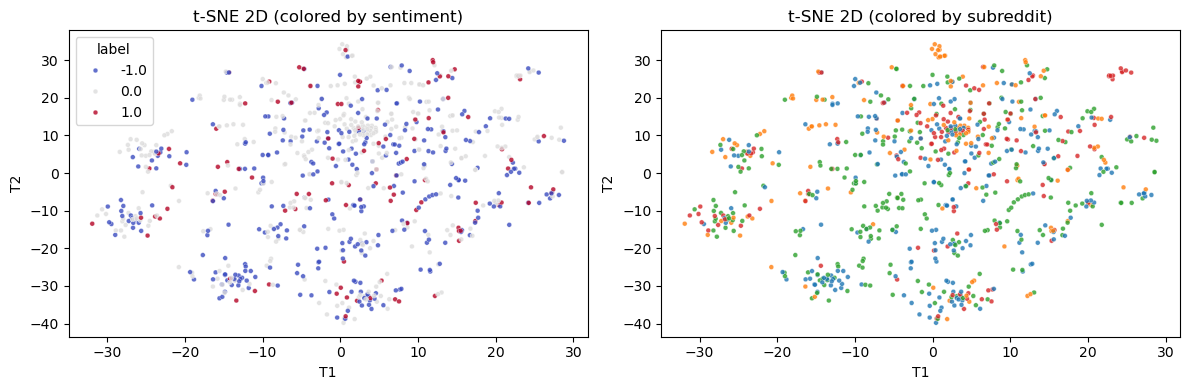

In [54]:
# Plot t-SNE 2D
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Colored by sentiment label
if 'label' in tsne2d_df.columns:
    sns.scatterplot(
        data=tsne2d_df.sample(min(3000, len(tsne2d_df)), random_state=42),
        x='T1', y='T2', hue='label', palette='coolwarm', s=12, ax=ax[0], alpha=0.8
    )
    ax[0].set_title('t-SNE 2D (colored by sentiment)')
else:
    ax[0].scatter(tsne2d_df['T1'], tsne2d_df['T2'], s=8, alpha=0.7)
    ax[0].set_title('t-SNE 2D')
ax[0].set_xlabel('T1')
ax[0].set_ylabel('T2')

# Colored by subreddit
if 'subreddit' in tsne2d_df.columns:
    sns.scatterplot(
        data=tsne2d_df.sample(min(3000, len(tsne2d_df)), random_state=42),
        x='T1', y='T2', hue='subreddit', s=12, ax=ax[1], alpha=0.8, legend=False
    )
    ax[1].set_title('t-SNE 2D (colored by subreddit)')
else:
    ax[1].scatter(tsne2d_df['T1'], tsne2d_df['T2'], s=8, alpha=0.7)
    ax[1].set_title('t-SNE 2D')
ax[1].set_xlabel('T1')
ax[1].set_ylabel('T2')

plt.tight_layout()
plt.show()

In [ ]:
print("""
The embeddings show recognizable topical structure: documents form loose clusters by subreddit,
 but boundaries aren’t perfectly sharp.
""")

# Data Classification

In [61]:
# Prepare input data
texts = X["text"].fillna("").astype(str).values
labels = X["label"].astype(float).values  # -1.0, 0.0, 1.0

In [62]:
# Multinomial Naive Bayes ===

# Split train/test sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# Vectorize text using Bag-of-Words
vectorizer = CountVectorizer(stop_words="english", min_df=3)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

# Train and evaluate Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Report results
accuracy = accuracy_score(y_test, y_pred)
print(f"Bag-of-Words + MultinomialNB accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred, digits=3))

Bag-of-Words + MultinomialNB accuracy: 0.5521
              precision    recall  f1-score   support

        -1.0      0.521     0.587     0.552        63
         0.0      0.602     0.641     0.621        78
         1.0      0.333     0.136     0.194        22

    accuracy                          0.552       163
   macro avg      0.486     0.455     0.456       163
weighted avg      0.535     0.552     0.537       163



In [63]:
# Decision Tree Classifier

# Split train/test sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# Vectorize text using Bag-of-Words
vectorizer = CountVectorizer(stop_words="english", min_df=3)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

# Train and evaluate Decision Tree classifier
model = DecisionTreeClassifier(
    criterion="entropy",    # or "gini"
    max_depth=20,           # limit depth to prevent overfitting
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Report results
accuracy = accuracy_score(y_test, y_pred)
print(f"Bag-of-Words + Decision Tree accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred, digits=3))

Bag-of-Words + Decision Tree accuracy: 0.5215
              precision    recall  f1-score   support

        -1.0      0.581     0.286     0.383        63
         0.0      0.525     0.808     0.636        78
         1.0      0.333     0.182     0.235        22

    accuracy                          0.521       163
   macro avg      0.480     0.425     0.418       163
weighted avg      0.521     0.521     0.484       163



In [64]:


# Random Forest Classifier

# Split train/test sets
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

# Vectorize text using Bag-of-Words
vectorizer = CountVectorizer(stop_words="english", min_df=3)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

# Train and evaluate Random Forest classifier
model = RandomForestClassifier(
    n_estimators=200,      # number of trees in the forest
    max_depth=30,          # control tree depth (None = fully grown)
    n_jobs=-1,             # use all CPU cores
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Report results
accuracy = accuracy_score(y_test, y_pred)
print(f"Bag-of-Words + Random Forest accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred, digits=3))

Bag-of-Words + Random Forest accuracy: 0.5521
              precision    recall  f1-score   support

        -1.0      0.594     0.302     0.400        63
         0.0      0.546     0.910     0.683        78
         1.0      0.000     0.000     0.000        22

    accuracy                          0.552       163
   macro avg      0.380     0.404     0.361       163
weighted avg      0.491     0.552     0.481       163



In [ ]:
print("""
Baselines with bag‑of‑words yield ~0.55 accuracy for MultinomialNB/Random Forest and ~0.52 for Decision Tree. Neutral is predicted best.
""")